# Push-Up Feature Engineering

This notebook computes frame-level and video-level features from MMPose keypoints.

It extracts joint angles and body alignment measures, applies temporal smoothing,
and aggregates them into features used for rule-based evaluation and ML models.

This notebook is mainly used for comparison purposes with MediaPipe in notebook 04.

In [1]:
import os
import json
import pandas as pd
from tqdm import tqdm

In [ ]:
from pathlib import Path

# Project root (notebook inside /notebooks)
PROJECT_ROOT = Path.cwd().parent

# Input directories (JSON from pose estimation)
KEYPOINTS_JSON_DIR = PROJECT_ROOT / "data" / "interim" / "keypoints_json"
POSE2D_DIR = KEYPOINTS_JSON_DIR / "pose2d"
POSE3D_DIR = KEYPOINTS_JSON_DIR / "body3d"

# Output directory
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Output files
FRAME_FEATURES_PATH = PROCESSED_DIR / "mmpose_2d_features_frame_level.csv"
VIDEO_FEATURES_PATH = PROCESSED_DIR / "mmpose_2d_features_video_level.csv"

# Debug
print("POSE2D_DIR:", POSE2D_DIR)
print("POSE3D_DIR:", POSE3D_DIR)
print("Output dir:", PROCESSED_DIR)

In [ ]:
def list_videos(POSE2D_DIR):
    videos = []
    
    for label in ["correct", "incorrect"]:
        label_dir = os.path.join(POSE2D_DIR, label)
        
        for file in os.listdir(label_dir):
            if file.endswith(".json"):
                videos.append({
                    "file": os.path.join(label_dir, file),
                    "label": label,
                    "video": file.replace(".json", "")
                })
    
    return videos

videos_2d = list_videos(POSE2D_DIR)
videos_3d = list_videos(POSE3D_DIR)

print(f"2D videos: {len(videos_2d)}")
print(f"3D videos: {len(videos_3d)}")

2D videos: 100
3D videos: 100


In [4]:
with open(videos_2d[0]["file"], "r") as f:
    data = json.load(f)

print(type(data))
print(data.keys() if isinstance(data, dict) else "list")

<class 'list'>
list


In [5]:
with open(videos_2d[0]["file"], "r", encoding="utf-8") as f:
    data_2d = json.load(f)

print("TYPE:", type(data_2d))

if isinstance(data_2d, dict):
    print("TOP-LEVEL KEYS:", list(data_2d.keys()))
    for k, v in data_2d.items():
        print(f"\nKEY: {k}")
        print("VALUE TYPE:", type(v))
        if isinstance(v, list):
            print("LIST LENGTH:", len(v))
            if len(v) > 0:
                print("FIRST ITEM TYPE:", type(v[0]))
                if isinstance(v[0], dict):
                    print("FIRST ITEM KEYS:", list(v[0].keys()))
        elif isinstance(v, dict):
            print("DICT KEYS:", list(v.keys()))
elif isinstance(data_2d, list):
    print("LIST LENGTH:", len(data_2d))
    if len(data_2d) > 0:
        print("FIRST ITEM TYPE:", type(data_2d[0]))
        if isinstance(data_2d[0], dict):
            print("FIRST ITEM KEYS:", list(data_2d[0].keys()))

TYPE: <class 'list'>
LIST LENGTH: 61
FIRST ITEM TYPE: <class 'dict'>
FIRST ITEM KEYS: ['frame_id', 'instances']


In [6]:
with open(videos_3d[0]["file"], "r", encoding="utf-8") as f:
    data_3d = json.load(f)

print("TYPE:", type(data_3d))

if isinstance(data_3d, dict):
    print("TOP-LEVEL KEYS:", list(data_3d.keys()))
    for k, v in data_3d.items():
        print(f"\nKEY: {k}")
        print("VALUE TYPE:", type(v))
        if isinstance(v, list):
            print("LIST LENGTH:", len(v))
            if len(v) > 0:
                print("FIRST ITEM TYPE:", type(v[0]))
                if isinstance(v[0], dict):
                    print("FIRST ITEM KEYS:", list(v[0].keys()))
        elif isinstance(v, dict):
            print("DICT KEYS:", list(v.keys()))
elif isinstance(data_3d, list):
    print("LIST LENGTH:", len(data_3d))
    if len(data_3d) > 0:
        print("FIRST ITEM TYPE:", type(data_3d[0]))
        if isinstance(data_3d[0], dict):
            print("FIRST ITEM KEYS:", list(data_3d[0].keys()))

TYPE: <class 'dict'>
TOP-LEVEL KEYS: ['meta_info', 'instance_info']

KEY: meta_info
VALUE TYPE: <class 'dict'>
DICT KEYS: ['dataset_name', 'num_keypoints', 'keypoint_id2name', 'keypoint_name2id', 'upper_body_ids', 'lower_body_ids', 'flip_indices', 'flip_pairs', 'keypoint_colors', 'num_skeleton_links', 'skeleton_links', 'skeleton_link_colors', 'dataset_keypoint_weights', 'sigmas', 'stats_info']

KEY: instance_info
VALUE TYPE: <class 'list'>
LIST LENGTH: 61
FIRST ITEM TYPE: <class 'dict'>
FIRST ITEM KEYS: ['frame_id', 'instances']


In [7]:
with open(videos_3d[0]["file"], "r", encoding="utf-8") as f:
    data_3d = json.load(f)

frames_3d = data_3d["instance_info"]

print("Number of frames:", len(frames_3d))
print("First frame keys:", frames_3d[0].keys())
print("Instances length:", len(frames_3d[0]["instances"]))

first_inst = frames_3d[0]["instances"][0]
print("Instance keys:", first_inst.keys())

for k, v in first_inst.items():
    print(f"\nKEY: {k}")
    print("TYPE:", type(v))
    if isinstance(v, list):
        print("LEN:", len(v))
        if len(v) > 0:
            print("FIRST ELEMENT TYPE:", type(v[0]))
            print("FIRST ELEMENT:", v[0])

Number of frames: 61
First frame keys: dict_keys(['frame_id', 'instances'])
Instances length: 1
Instance keys: dict_keys(['keypoints', 'keypoint_scores'])

KEY: keypoints
TYPE: <class 'list'>
LEN: 17
FIRST ELEMENT TYPE: <class 'list'>
FIRST ELEMENT: [-0.0, 0.0, 0.49206018447875977]

KEY: keypoint_scores
TYPE: <class 'list'>
LEN: 17
FIRST ELEMENT TYPE: <class 'float'>
FIRST ELEMENT: 1.0


In [8]:
def json_to_df(video_info, modality="2d"):
    with open(video_info["file"], "r", encoding="utf-8") as f:
        data = json.load(f)

    rows = []

    # 2D: top-level is a list
    if modality == "2d":
        if isinstance(data, list):
            frames = data
        else:
            return pd.DataFrame()

    # 3D: top-level dict with instance_info
    elif modality == "3d":
        if isinstance(data, dict) and "instance_info" in data:
            frames = data["instance_info"]
        else:
            return pd.DataFrame()
    else:
        return pd.DataFrame()

    for frame_idx, frame in enumerate(frames):
        if not isinstance(frame, dict):
            continue
        if "instances" not in frame or len(frame["instances"]) == 0:
            continue

        inst = frame["instances"][0]

        # 2D and 3D both use "keypoints" in your files
        keypoints = inst.get("keypoints", None)
        keypoint_scores = inst.get("keypoint_scores", None)

        if keypoints is None:
            continue

        row = {}

        for i, kp in enumerate(keypoints):
            if not isinstance(kp, (list, tuple)):
                continue

            if len(kp) >= 2:
                row[f"kp_{i}_x"] = kp[0]
                row[f"kp_{i}_y"] = kp[1]

            if modality == "3d" and len(kp) >= 3:
                row[f"kp_{i}_z"] = kp[2]

            if keypoint_scores is not None and i < len(keypoint_scores):
                row[f"kp_{i}_score"] = keypoint_scores[i]

        row.update({
            "video": video_info["video"],
            "label": video_info["label"],
            "frame": frame.get("frame_id", frame_idx),
            "modality": modality,
            "source": "mmpose"
        })

        rows.append(row)

    return pd.DataFrame(rows)

In [9]:
test_df_2d = json_to_df(videos_2d[0], "2d")
test_df_3d = json_to_df(videos_3d[0], "3d")

print("test_df_2d shape:", test_df_2d.shape)
print("test_df_3d shape:", test_df_3d.shape)

display(test_df_2d.head())
display(test_df_3d.head())

test_df_2d shape: (61, 56)
test_df_3d shape: (61, 73)


,kp_0_x,kp_0_y,kp_0_score,kp_1_x,kp_1_y,kp_1_score,kp_2_x,kp_2_y,kp_2_score,kp_3_x,...,kp_15_y,kp_15_score,kp_16_x,kp_16_y,kp_16_score,video,label,frame,modality,source
0,470.278442,209.123871,0.767201,480.051208,200.979919,0.573068,478.422394,197.722336,0.750955,468.649658,...,284.048248,0.895778,46.792831,293.820984,0.930228,Copy of push up 1,correct,0,2d,mmpose
1,471.432617,207.798691,0.784137,481.191101,199.666641,0.590357,477.938263,198.040237,0.762666,468.179810,...,282.613556,0.905938,48.565983,292.372009,0.938312,Copy of push up 1,correct,1,2d,mmpose
2,469.808624,208.009949,0.789959,481.196136,199.875992,0.599797,477.942566,198.249191,0.766855,466.555023,...,282.842316,0.911388,46.843037,294.229858,0.941272,Copy of push up 1,correct,2,2d,mmpose
3,470.608124,208.355255,0.797917,480.381104,200.211105,0.601915,478.752289,198.582275,0.782718,467.350464,...,283.281433,0.917250,47.112389,293.054413,0.944427,Copy of push up 1,correct,3,2d,mmpose
4,470.624359,207.818115,0.801021,480.486938,199.599274,0.602284,477.199432,197.955505,0.781267,467.336823,...,283.431335,0.909034,46.532703,296.581482,0.934865,Copy of push up 1,correct,4,2d,mmpose


,kp_0_x,kp_0_y,kp_0_z,kp_0_score,kp_1_x,kp_1_y,kp_1_z,kp_1_score,kp_2_x,kp_2_y,...,kp_15_score,kp_16_x,kp_16_y,kp_16_z,kp_16_score,video,label,frame,modality,source
0,-0.0,0.0,0.492060,1.0,-0.100148,-0.054207,0.564922,1.0,0.031400,0.028057,...,1.0,0.003824,0.042036,0.265593,1.0,Copy of push up 1,correct,1,3d,mmpose
1,-0.0,0.0,0.485601,1.0,-0.102196,-0.054988,0.561710,1.0,0.031362,0.027462,...,1.0,0.003433,0.040715,0.261895,1.0,Copy of push up 1,correct,2,3d,mmpose
2,-0.0,0.0,0.485607,1.0,-0.100292,-0.053781,0.557589,1.0,0.032384,0.027137,...,1.0,0.002292,0.039402,0.266552,1.0,Copy of push up 1,correct,3,3d,mmpose
3,-0.0,0.0,0.478458,1.0,-0.100951,-0.053684,0.552729,1.0,0.027938,0.026494,...,1.0,0.002749,0.038964,0.261462,1.0,Copy of push up 1,correct,4,3d,mmpose
4,-0.0,0.0,0.478242,1.0,-0.104197,-0.054964,0.558083,1.0,0.028328,0.025345,...,1.0,0.000353,0.034748,0.272990,1.0,Copy of push up 1,correct,5,3d,mmpose


In [10]:
dfs_2d = []
for v in tqdm(videos_2d):
    try:
        df_tmp = json_to_df(v, "2d")
        if not df_tmp.empty:
            dfs_2d.append(df_tmp)
    except Exception as e:
        print(f"Error in 2D file {v['video']}: {e}")

df_2d = pd.concat(dfs_2d, ignore_index=True) if dfs_2d else pd.DataFrame()


dfs_3d = []
for v in tqdm(videos_3d):
    try:
        df_tmp = json_to_df(v, "3d")
        if not df_tmp.empty:
            dfs_3d.append(df_tmp)
    except Exception as e:
        print(f"Error in 3D file {v['video']}: {e}")

df_3d = pd.concat(dfs_3d, ignore_index=True) if dfs_3d else pd.DataFrame()

print("df_2d shape:", df_2d.shape)
print("df_3d shape:", df_3d.shape)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:01<00:00, 66.19it/s]

df_2d shape: (10928, 56)
df_3d shape: (10928, 73)


In [11]:
print("2D labels:")
print(df_2d["label"].value_counts())

print("\n3D labels:")
print(df_3d["label"].value_counts())

print("\n2D videos:", df_2d["video"].nunique())
print("3D videos:", df_3d["video"].nunique())

2D labels:
label
incorrect    6425
correct      4503
Name: count, dtype: int64

3D labels:
label
incorrect    6425
correct      4503
Name: count, dtype: int64

2D videos: 100
3D videos: 100


In [12]:
print("2D columns:")
print(df_2d.columns.tolist())

print("\n3D columns:")
print(df_3d.columns.tolist())

2D columns:
['kp_0_x', 'kp_0_y', 'kp_0_score', 'kp_1_x', 'kp_1_y', 'kp_1_score', 'kp_2_x', 'kp_2_y', 'kp_2_score', 'kp_3_x', 'kp_3_y', 'kp_3_score', 'kp_4_x', 'kp_4_y', 'kp_4_score', 'kp_5_x', 'kp_5_y', 'kp_5_score', 'kp_6_x', 'kp_6_y', 'kp_6_score', 'kp_7_x', 'kp_7_y', 'kp_7_score', 'kp_8_x', 'kp_8_y', 'kp_8_score', 'kp_9_x', 'kp_9_y', 'kp_9_score', 'kp_10_x', 'kp_10_y', 'kp_10_score', 'kp_11_x', 'kp_11_y', 'kp_11_score', 'kp_12_x', 'kp_12_y', 'kp_12_score', 'kp_13_x', 'kp_13_y', 'kp_13_score', 'kp_14_x', 'kp_14_y', 'kp_14_score', 'kp_15_x', 'kp_15_y', 'kp_15_score', 'kp_16_x', 'kp_16_y', 'kp_16_score', 'video', 'label', 'frame', 'modality', 'source']

3D columns:
['kp_0_x', 'kp_0_y', 'kp_0_z', 'kp_0_score', 'kp_1_x', 'kp_1_y', 'kp_1_z', 'kp_1_score', 'kp_2_x', 'kp_2_y', 'kp_2_z', 'kp_2_score', 'kp_3_x', 'kp_3_y', 'kp_3_z', 'kp_3_score', 'kp_4_x', 'kp_4_y', 'kp_4_z', 'kp_4_score', 'kp_5_x', 'kp_5_y', 'kp_5_z', 'kp_5_score', 'kp_6_x', 'kp_6_y', 'kp_6_z', 'kp_6_score', 'kp_7_x', 'kp_7_y

In [13]:
display(df_2d.head())
display(df_3d.head())

,kp_0_x,kp_0_y,kp_0_score,kp_1_x,kp_1_y,kp_1_score,kp_2_x,kp_2_y,kp_2_score,kp_3_x,...,kp_15_y,kp_15_score,kp_16_x,kp_16_y,kp_16_score,video,label,frame,modality,source
0,470.278442,209.123871,0.767201,480.051208,200.979919,0.573068,478.422394,197.722336,0.750955,468.649658,...,284.048248,0.895778,46.792831,293.820984,0.930228,Copy of push up 1,correct,0,2d,mmpose
1,471.432617,207.798691,0.784137,481.191101,199.666641,0.590357,477.938263,198.040237,0.762666,468.179810,...,282.613556,0.905938,48.565983,292.372009,0.938312,Copy of push up 1,correct,1,2d,mmpose
2,469.808624,208.009949,0.789959,481.196136,199.875992,0.599797,477.942566,198.249191,0.766855,466.555023,...,282.842316,0.911388,46.843037,294.229858,0.941272,Copy of push up 1,correct,2,2d,mmpose
3,470.608124,208.355255,0.797917,480.381104,200.211105,0.601915,478.752289,198.582275,0.782718,467.350464,...,283.281433,0.917250,47.112389,293.054413,0.944427,Copy of push up 1,correct,3,2d,mmpose
4,470.624359,207.818115,0.801021,480.486938,199.599274,0.602284,477.199432,197.955505,0.781267,467.336823,...,283.431335,0.909034,46.532703,296.581482,0.934865,Copy of push up 1,correct,4,2d,mmpose


,kp_0_x,kp_0_y,kp_0_z,kp_0_score,kp_1_x,kp_1_y,kp_1_z,kp_1_score,kp_2_x,kp_2_y,...,kp_15_score,kp_16_x,kp_16_y,kp_16_z,kp_16_score,video,label,frame,modality,source
0,-0.0,0.0,0.492060,1.0,-0.100148,-0.054207,0.564922,1.0,0.031400,0.028057,...,1.0,0.003824,0.042036,0.265593,1.0,Copy of push up 1,correct,1,3d,mmpose
1,-0.0,0.0,0.485601,1.0,-0.102196,-0.054988,0.561710,1.0,0.031362,0.027462,...,1.0,0.003433,0.040715,0.261895,1.0,Copy of push up 1,correct,2,3d,mmpose
2,-0.0,0.0,0.485607,1.0,-0.100292,-0.053781,0.557589,1.0,0.032384,0.027137,...,1.0,0.002292,0.039402,0.266552,1.0,Copy of push up 1,correct,3,3d,mmpose
3,-0.0,0.0,0.478458,1.0,-0.100951,-0.053684,0.552729,1.0,0.027938,0.026494,...,1.0,0.002749,0.038964,0.261462,1.0,Copy of push up 1,correct,4,3d,mmpose
4,-0.0,0.0,0.478242,1.0,-0.104197,-0.054964,0.558083,1.0,0.028328,0.025345,...,1.0,0.000353,0.034748,0.272990,1.0,Copy of push up 1,correct,5,3d,mmpose


In [15]:
import numpy as np

def compute_angle(a, b, c):
    a = np.array(a)
    b = np.array(b)
    c = np.array(c)

    ba = a - b
    bc = c - b

    cos_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))
    return np.degrees(np.arccos(np.clip(cos_angle, -1.0, 1.0)))

In [16]:
def add_elbow_angles(df, is_3d=False):
    left_angles = []
    right_angles = []

    for _, row in df.iterrows():
        try:
            # LEFT
            l_shoulder = (row["kp_5_x"], row["kp_5_y"])
            l_elbow = (row["kp_7_x"], row["kp_7_y"])
            l_wrist = (row["kp_9_x"], row["kp_9_y"])

            # RIGHT
            r_shoulder = (row["kp_6_x"], row["kp_6_y"])
            r_elbow = (row["kp_8_x"], row["kp_8_y"])
            r_wrist = (row["kp_10_x"], row["kp_10_y"])

            left_angles.append(compute_angle(l_shoulder, l_elbow, l_wrist))
            right_angles.append(compute_angle(r_shoulder, r_elbow, r_wrist))

        except:
            left_angles.append(None)
            right_angles.append(None)

    df["left_elbow_angle"] = left_angles
    df["right_elbow_angle"] = right_angles

    return df

In [17]:
df_2d = add_elbow_angles(df_2d, is_3d=False)
df_3d = add_elbow_angles(df_3d, is_3d=True)

print(df_2d[["left_elbow_angle", "right_elbow_angle"]].head())
print(df_3d[["left_elbow_angle", "right_elbow_angle"]].head())

   left_elbow_angle  right_elbow_angle
0        164.131150         164.933183
1        165.518616         164.966630
2        168.378031         167.207485
3        167.986596         165.920335
4        169.855369         167.190759
   left_elbow_angle  right_elbow_angle
0          6.701952           9.234100
1          7.541547           9.656549
2          7.942259           9.243244
3          9.653066           9.314807
4         12.250177           7.774823


In [18]:
COCO_KP = {
    "nose": 0,
    "left_eye": 1,
    "right_eye": 2,
    "left_ear": 3,
    "right_ear": 4,
    "left_shoulder": 5,
    "right_shoulder": 6,
    "left_elbow": 7,
    "right_elbow": 8,
    "left_wrist": 9,
    "right_wrist": 10,
    "left_hip": 11,
    "right_hip": 12,
    "left_knee": 13,
    "right_knee": 14,
    "left_ankle": 15,
    "right_ankle": 16
}

In [19]:
import numpy as np

def compute_angle_2d(a, b, c):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    c = np.array(c, dtype=float)

    ba = a - b
    bc = c - b

    denom = np.linalg.norm(ba) * np.linalg.norm(bc)
    if denom == 0:
        return np.nan

    cos_angle = np.dot(ba, bc) / denom
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_angle)))


def compute_angle_3d(a, b, c):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    c = np.array(c, dtype=float)

    ba = a - b
    bc = c - b

    denom = np.linalg.norm(ba) * np.linalg.norm(bc)
    if denom == 0:
        return np.nan

    cos_angle = np.dot(ba, bc) / denom
    cos_angle = np.clip(cos_angle, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos_angle)))


def compute_distance_2d(a, b):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    return float(np.linalg.norm(a - b))


def compute_distance_3d(a, b):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    return float(np.linalg.norm(a - b))

In [20]:
def get_point_2d(row, idx):
    return (row[f"kp_{idx}_x"], row[f"kp_{idx}_y"])


def get_point_3d(row, idx):
    return (row[f"kp_{idx}_x"], row[f"kp_{idx}_y"], row[f"kp_{idx}_z"])


def get_score(row, idx):
    col = f"kp_{idx}_score"
    return row[col] if col in row.index else np.nan

In [21]:
def add_side_features(df, modality="2d"):
    left_elbow_angles = []
    right_elbow_angles = []

    left_body_alignment_angles = []
    right_body_alignment_angles = []

    left_hip_angles = []
    right_hip_angles = []

    left_shoulder_wrist_distances = []
    right_shoulder_wrist_distances = []

    left_side_scores = []
    right_side_scores = []

    for _, row in df.iterrows():
        try:
            if modality == "2d":
                get_point = get_point_2d
                angle_fn = compute_angle_2d
                dist_fn = compute_distance_2d
            else:
                get_point = get_point_3d
                angle_fn = compute_angle_3d
                dist_fn = compute_distance_3d

            # left side
            l_shoulder = get_point(row, COCO_KP["left_shoulder"])
            l_elbow = get_point(row, COCO_KP["left_elbow"])
            l_wrist = get_point(row, COCO_KP["left_wrist"])
            l_hip = get_point(row, COCO_KP["left_hip"])
            l_knee = get_point(row, COCO_KP["left_knee"])
            l_ankle = get_point(row, COCO_KP["left_ankle"])

            # right side
            r_shoulder = get_point(row, COCO_KP["right_shoulder"])
            r_elbow = get_point(row, COCO_KP["right_elbow"])
            r_wrist = get_point(row, COCO_KP["right_wrist"])
            r_hip = get_point(row, COCO_KP["right_hip"])
            r_knee = get_point(row, COCO_KP["right_knee"])
            r_ankle = get_point(row, COCO_KP["right_ankle"])

            # angles
            left_elbow_angles.append(angle_fn(l_shoulder, l_elbow, l_wrist))
            right_elbow_angles.append(angle_fn(r_shoulder, r_elbow, r_wrist))

            left_body_alignment_angles.append(angle_fn(l_shoulder, l_hip, l_ankle))
            right_body_alignment_angles.append(angle_fn(r_shoulder, r_hip, r_ankle))

            left_hip_angles.append(angle_fn(l_shoulder, l_hip, l_knee))
            right_hip_angles.append(angle_fn(r_shoulder, r_hip, r_knee))

            # distances
            left_shoulder_wrist_distances.append(dist_fn(l_shoulder, l_wrist))
            right_shoulder_wrist_distances.append(dist_fn(r_shoulder, r_wrist))

            # reliability scores
            left_side_scores.append(np.nanmean([
                get_score(row, COCO_KP["left_shoulder"]),
                get_score(row, COCO_KP["left_elbow"]),
                get_score(row, COCO_KP["left_wrist"]),
                get_score(row, COCO_KP["left_hip"]),
                get_score(row, COCO_KP["left_knee"]),
                get_score(row, COCO_KP["left_ankle"]),
            ]))

            right_side_scores.append(np.nanmean([
                get_score(row, COCO_KP["right_shoulder"]),
                get_score(row, COCO_KP["right_elbow"]),
                get_score(row, COCO_KP["right_wrist"]),
                get_score(row, COCO_KP["right_hip"]),
                get_score(row, COCO_KP["right_knee"]),
                get_score(row, COCO_KP["right_ankle"]),
            ]))

        except Exception:
            left_elbow_angles.append(np.nan)
            right_elbow_angles.append(np.nan)
            left_body_alignment_angles.append(np.nan)
            right_body_alignment_angles.append(np.nan)
            left_hip_angles.append(np.nan)
            right_hip_angles.append(np.nan)
            left_shoulder_wrist_distances.append(np.nan)
            right_shoulder_wrist_distances.append(np.nan)
            left_side_scores.append(np.nan)
            right_side_scores.append(np.nan)

    df = df.copy()

    df["left_elbow_angle"] = left_elbow_angles
    df["right_elbow_angle"] = right_elbow_angles

    df["left_body_alignment_angle"] = left_body_alignment_angles
    df["right_body_alignment_angle"] = right_body_alignment_angles

    df["left_hip_angle"] = left_hip_angles
    df["right_hip_angle"] = right_hip_angles

    df["left_shoulder_wrist_distance"] = left_shoulder_wrist_distances
    df["right_shoulder_wrist_distance"] = right_shoulder_wrist_distances

    df["left_side_score"] = left_side_scores
    df["right_side_score"] = right_side_scores

    return df

In [22]:
df_2d = add_side_features(df_2d, modality="2d")
df_3d = add_side_features(df_3d, modality="3d")

display(df_2d[[
    "left_elbow_angle", "right_elbow_angle",
    "left_body_alignment_angle", "right_body_alignment_angle",
    "left_hip_angle", "right_hip_angle"
]].head())

display(df_3d[[
    "left_elbow_angle", "right_elbow_angle",
    "left_body_alignment_angle", "right_body_alignment_angle",
    "left_hip_angle", "right_hip_angle"
]].head())

,left_elbow_angle,right_elbow_angle,left_body_alignment_angle,right_body_alignment_angle,left_hip_angle,right_hip_angle
0,164.131150,164.933183,148.392500,144.221388,145.279060,143.460561
1,165.518616,164.966630,149.688788,145.061357,147.094758,144.301975
2,168.378031,167.207485,150.662103,146.663068,148.118853,146.830111
3,167.986596,165.920335,151.840475,146.327471,149.600519,145.838055
4,169.855369,167.190759,153.838433,147.130654,151.303739,146.984612


,left_elbow_angle,right_elbow_angle,left_body_alignment_angle,right_body_alignment_angle,left_hip_angle,right_hip_angle
0,54.642933,48.393172,10.904110,22.966480,6.332420,137.385783
1,58.857928,49.221304,11.291343,23.427274,6.007186,138.956092
2,61.362163,49.338000,11.560905,23.570208,6.026813,138.747075
3,64.867268,54.591619,11.437568,23.357580,5.556358,138.127572
4,65.780027,48.208550,12.111041,23.365531,4.972114,139.455828


In [23]:
def select_best_side(df):
    df = df.copy()

    df["selected_side"] = np.where(
        df["left_side_score"] >= df["right_side_score"],
        "left",
        "right"
    )

    df["elbow_angle"] = np.where(
        df["selected_side"] == "left",
        df["left_elbow_angle"],
        df["right_elbow_angle"]
    )

    df["body_alignment_angle"] = np.where(
        df["selected_side"] == "left",
        df["left_body_alignment_angle"],
        df["right_body_alignment_angle"]
    )

    df["hip_angle"] = np.where(
        df["selected_side"] == "left",
        df["left_hip_angle"],
        df["right_hip_angle"]
    )

    df["shoulder_wrist_distance"] = np.where(
        df["selected_side"] == "left",
        df["left_shoulder_wrist_distance"],
        df["right_shoulder_wrist_distance"]
    )

    df["selected_side_score"] = np.where(
        df["selected_side"] == "left",
        df["left_side_score"],
        df["right_side_score"]
    )

    return df

In [24]:
df_2d = select_best_side(df_2d)
df_3d = select_best_side(df_3d)

display(df_2d[[
    "selected_side", "selected_side_score",
    "elbow_angle", "body_alignment_angle", "hip_angle",
    "shoulder_wrist_distance"
]].head())

display(df_3d[[
    "selected_side", "selected_side_score",
    "elbow_angle", "body_alignment_angle", "hip_angle",
    "shoulder_wrist_distance"
]].head())

,selected_side,selected_side_score,elbow_angle,body_alignment_angle,hip_angle,shoulder_wrist_distance
0,right,0.850036,164.933183,144.221388,143.460561,165.023120
1,right,0.857041,164.966630,145.061357,144.301975,166.403309
2,right,0.858447,167.207485,146.663068,146.830111,166.442215
3,right,0.865772,165.920335,146.327471,145.838055,165.163662
4,right,0.866404,167.190759,147.130654,146.984612,166.540368


,selected_side,selected_side_score,elbow_angle,body_alignment_angle,hip_angle,shoulder_wrist_distance
0,left,1.0,54.642933,10.904110,6.332420,0.334921
1,left,1.0,58.857928,11.291343,6.007186,0.336259
2,left,1.0,61.362163,11.560905,6.026813,0.342146
3,left,1.0,64.867268,11.437568,5.556358,0.334846
4,left,1.0,65.780027,12.111041,4.972114,0.339512


In [25]:
def smooth_features_per_video(
    df,
    feature_cols,
    window=5,
    min_periods=1
):
    df = df.sort_values(["video", "frame"]).copy()

    for col in feature_cols:
        smooth_col = f"{col}_smooth"
        df[smooth_col] = (
            df.groupby("video")[col]
            .transform(lambda s: s.rolling(window=window, min_periods=min_periods, center=True).mean())
        )

    return df

In [26]:
feature_cols_to_smooth = [
    "elbow_angle",
    "body_alignment_angle",
    "hip_angle",
    "shoulder_wrist_distance"
]

df_2d = smooth_features_per_video(df_2d, feature_cols_to_smooth, window=5)
df_3d = smooth_features_per_video(df_3d, feature_cols_to_smooth, window=5)

display(df_2d[[
    "video", "frame",
    "elbow_angle", "elbow_angle_smooth",
    "body_alignment_angle", "body_alignment_angle_smooth"
]].head(10))

display(df_3d[[
    "video", "frame",
    "elbow_angle", "elbow_angle_smooth",
    "body_alignment_angle", "body_alignment_angle_smooth"
]].head(10))

,video,frame,elbow_angle,elbow_angle_smooth,body_alignment_angle,body_alignment_angle_smooth
4503,1,0,173.796556,172.912117,178.066698,178.019635
4504,1,1,173.659803,172.546718,177.805068,178.129518
4505,1,2,171.279991,172.769336,178.187137,177.967856
4506,1,3,171.450524,172.741984,178.459169,178.024203
4507,1,4,173.659807,172.713409,177.321204,177.979973
4508,1,5,173.659795,172.747513,178.348436,177.851543
4509,1,6,173.516926,172.747508,177.583919,178.015964
4510,1,7,171.450515,172.274673,177.544987,178.468712
4511,1,8,171.450498,171.832819,179.281273,178.633760
4512,1,9,171.295629,171.670429,179.584943,179.033965


,video,frame,elbow_angle,elbow_angle_smooth,body_alignment_angle,body_alignment_angle_smooth
4503,1,1,75.450189,73.528539,32.566721,32.325898
4504,1,2,72.854222,73.283157,32.267341,32.657484
4505,1,3,72.281204,73.958786,32.143631,32.821700
4506,1,4,72.547013,73.635760,33.652243,32.961334
4507,1,5,76.661300,73.077652,33.478564,32.739730
4508,1,6,73.835060,73.488811,33.264890,32.990347
4509,1,7,70.063682,75.138225,31.159320,32.844474
4510,1,8,74.337001,74.826437,33.396718,32.509068
4511,1,9,80.794084,76.603848,32.922880,32.762854
4512,1,10,75.102359,78.953924,31.801532,33.167527


In [27]:
def add_phase_from_elbow(df):
    df = df.copy()

    angle_col = "elbow_angle_smooth" if "elbow_angle_smooth" in df.columns else "elbow_angle"

    conditions = [
        df[angle_col] < 90,
        (df[angle_col] >= 90) & (df[angle_col] < 140),
        (df[angle_col] >= 140) & (df[angle_col] < 165),
        df[angle_col] >= 165
    ]
    choices = ["bottom", "down_up_transition", "up_down_transition", "top"]

    df["phase"] = np.select(conditions, choices, default="unknown")

    return df

In [28]:
df_2d = add_phase_from_elbow(df_2d)
df_3d = add_phase_from_elbow(df_3d)

print(df_2d["phase"].value_counts(dropna=False))
print(df_3d["phase"].value_counts(dropna=False))

phase
top                   3749
up_down_transition    2734
down_up_transition    2604
bottom                1841
Name: count, dtype: int64
phase
bottom                6214
down_up_transition    3859
up_down_transition     855
Name: count, dtype: int64


In [ ]:
OUTPUT_DIR = PROCESSED_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

Saved frame-level feature files.


In [30]:
video_level_2d = (
    df_2d.groupby(["video", "label"], as_index=False)
    .agg(
        n_frames=("frame", "count"),
        selected_side_score_mean=("selected_side_score", "mean"),

        elbow_angle_mean=("elbow_angle_smooth", "mean"),
        elbow_angle_min=("elbow_angle_smooth", "min"),
        elbow_angle_max=("elbow_angle_smooth", "max"),
        elbow_angle_std=("elbow_angle_smooth", "std"),

        body_alignment_angle_mean=("body_alignment_angle_smooth", "mean"),
        body_alignment_angle_min=("body_alignment_angle_smooth", "min"),
        body_alignment_angle_std=("body_alignment_angle_smooth", "std"),

        hip_angle_mean=("hip_angle_smooth", "mean"),
        hip_angle_min=("hip_angle_smooth", "min"),
        hip_angle_std=("hip_angle_smooth", "std"),

        shoulder_wrist_distance_mean=("shoulder_wrist_distance_smooth", "mean"),
        shoulder_wrist_distance_min=("shoulder_wrist_distance_smooth", "min"),
        shoulder_wrist_distance_max=("shoulder_wrist_distance_smooth", "max"),
        shoulder_wrist_distance_std=("shoulder_wrist_distance_smooth", "std"),
    )
)

video_level_3d = (
    df_3d.groupby(["video", "label"], as_index=False)
    .agg(
        n_frames=("frame", "count"),
        selected_side_score_mean=("selected_side_score", "mean"),

        elbow_angle_mean=("elbow_angle_smooth", "mean"),
        elbow_angle_min=("elbow_angle_smooth", "min"),
        elbow_angle_max=("elbow_angle_smooth", "max"),
        elbow_angle_std=("elbow_angle_smooth", "std"),

        body_alignment_angle_mean=("body_alignment_angle_smooth", "mean"),
        body_alignment_angle_min=("body_alignment_angle_smooth", "min"),
        body_alignment_angle_std=("body_alignment_angle_smooth", "std"),

        hip_angle_mean=("hip_angle_smooth", "mean"),
        hip_angle_min=("hip_angle_smooth", "min"),
        hip_angle_std=("hip_angle_smooth", "std"),

        shoulder_wrist_distance_mean=("shoulder_wrist_distance_smooth", "mean"),
        shoulder_wrist_distance_min=("shoulder_wrist_distance_smooth", "min"),
        shoulder_wrist_distance_max=("shoulder_wrist_distance_smooth", "max"),
        shoulder_wrist_distance_std=("shoulder_wrist_distance_smooth", "std"),
    )
)

display(video_level_2d.head())
display(video_level_3d.head())

,video,label,n_frames,selected_side_score_mean,elbow_angle_mean,elbow_angle_min,elbow_angle_max,elbow_angle_std,body_alignment_angle_mean,body_alignment_angle_min,body_alignment_angle_std,hip_angle_mean,hip_angle_min,hip_angle_std,shoulder_wrist_distance_mean,shoulder_wrist_distance_min,shoulder_wrist_distance_max,shoulder_wrist_distance_std
0,1,incorrect,290,0.757106,139.836116,79.523280,178.355548,32.427363,165.431101,150.984762,9.099123,171.437653,161.561989,4.503636,124.535749,78.291885,165.860206,31.444292
1,10,incorrect,126,0.774020,154.250348,55.333089,179.541052,38.397612,171.834034,163.073746,5.120541,175.501285,169.421594,2.879700,118.551709,58.141868,146.765124,31.302232
2,11,incorrect,83,0.758007,163.994167,124.494976,179.081036,15.563101,164.632665,155.740955,5.773683,173.979290,166.455098,4.444051,112.161040,60.336301,150.448770,31.920339
3,12,incorrect,121,0.755539,161.651762,59.900305,179.568706,27.930260,170.284671,163.438837,6.210059,173.069652,166.624728,3.793907,123.914901,64.434577,152.610889,29.540137
4,13,incorrect,121,0.733399,140.289152,12.557434,179.602238,47.535370,166.953799,155.846772,7.004479,173.836609,163.334600,4.829285,99.153375,37.291164,148.907615,37.752808


,video,label,n_frames,selected_side_score_mean,elbow_angle_mean,elbow_angle_min,elbow_angle_max,elbow_angle_std,body_alignment_angle_mean,body_alignment_angle_min,body_alignment_angle_std,hip_angle_mean,hip_angle_min,hip_angle_std,shoulder_wrist_distance_mean,shoulder_wrist_distance_min,shoulder_wrist_distance_max,shoulder_wrist_distance_std
0,1,incorrect,290,1.0,57.694161,9.574832,110.512868,30.091181,49.857181,27.331614,24.514011,17.248027,6.030164,8.376752,0.317054,0.215649,0.417141,0.072193
1,10,incorrect,126,1.0,42.831888,21.346446,103.279841,22.839942,32.503644,19.283972,12.738865,12.925025,6.133053,7.440339,0.268663,0.204682,0.366946,0.047951
2,11,incorrect,83,1.0,71.365664,34.544372,102.130595,22.658233,24.822889,18.055936,4.178215,15.296840,7.078441,6.232976,0.290490,0.219865,0.363674,0.047839
3,12,incorrect,121,1.0,45.472792,17.820678,80.016593,16.667932,26.217819,14.836158,10.457418,11.824543,5.693894,6.184252,0.294001,0.211960,0.373684,0.044101
4,13,incorrect,121,1.0,44.004788,19.019039,73.790315,13.863865,34.251156,16.131722,25.465740,16.553870,4.707456,7.792593,0.259078,0.216089,0.325022,0.035349


In [31]:
video_level_2d.to_csv(os.path.join(OUTPUT_DIR, "mmpose_2d_features_video_level.csv"), index=False)
video_level_3d.to_csv(os.path.join(OUTPUT_DIR, "mmpose_3d_features_video_level.csv"), index=False)

print("Saved video-level feature files.")

Saved video-level feature files.


In [32]:
df_2d[["elbow_angle", "body_alignment_angle", "hip_angle"]].describe()

,elbow_angle,body_alignment_angle,hip_angle
count,10928.000000,10928.000000,10928.000000
mean,137.150138,170.174444,170.691333
std,38.297914,8.894035,7.794197
min,9.685808,144.221388,135.863694
25%,107.110777,164.097945,166.795573
50%,151.381490,173.758854,172.118966
75%,168.961402,177.405969,176.838996
max,180.000000,180.000000,180.000000


In [33]:
df_3d[["elbow_angle", "body_alignment_angle", "hip_angle"]].describe()

,elbow_angle,body_alignment_angle,hip_angle
count,10928.000000,10928.000000,10928.000000
mean,80.683447,36.581791,15.901348
std,40.497362,21.962000,11.860742
min,1.656686,10.904110,1.823784
25%,46.721687,23.693326,7.452625
50%,79.631420,31.158993,11.586999
75%,111.722998,41.999670,22.536705
max,160.382665,156.267926,128.694171


In [34]:
def normalize_distances_per_video(df, cols):
    df = df.copy()

    for col in cols:
        df[col + "_norm"] = df.groupby("video")[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min() + 1e-6)
        )

    return df

In [35]:
distance_cols = ["shoulder_wrist_distance"]

df_2d = normalize_distances_per_video(df_2d, distance_cols)
df_3d = normalize_distances_per_video(df_3d, distance_cols)

In [36]:
angle_cols = ["elbow_angle", "body_alignment_angle", "hip_angle"]

df_3d = normalize_distances_per_video(df_3d, angle_cols)

In [37]:
def normalize_per_video(df, cols):
    df = df.copy()

    for col in cols:
        df[f"{col}_norm"] = df.groupby("video")[col].transform(
            lambda x: (x - x.min()) / (x.max() - x.min() + 1e-6)
        )

    return df

In [38]:
cols_to_normalize_2d = [
    "shoulder_wrist_distance",
    "elbow_angle",
    "body_alignment_angle",
    "hip_angle"
]

cols_to_normalize_3d = [
    "shoulder_wrist_distance",
    "elbow_angle",
    "body_alignment_angle",
    "hip_angle"
]

df_2d = normalize_per_video(df_2d, cols_to_normalize_2d)
df_3d = normalize_per_video(df_3d, cols_to_normalize_3d)

In [39]:
import matplotlib.pyplot as plt

sample_video_2d = df_2d["video"].iloc[0]
sample_video_3d = df_3d["video"].iloc[0]

plot_df_2d = df_2d[df_2d["video"] == sample_video_2d].sort_values("frame")
plot_df_3d = df_3d[df_3d["video"] == sample_video_3d].sort_values("frame")

print("2D sample video:", sample_video_2d)
print("3D sample video:", sample_video_3d)

2D sample video: 1
3D sample video: 1


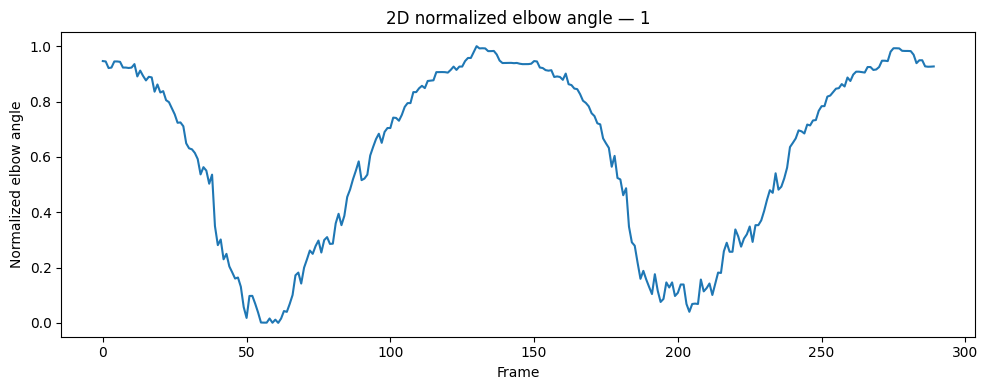

In [40]:
plt.figure(figsize=(10, 4))
plt.plot(plot_df_2d["frame"], plot_df_2d["elbow_angle_norm"])
plt.xlabel("Frame")
plt.ylabel("Normalized elbow angle")
plt.title(f"2D normalized elbow angle — {sample_video_2d}")
plt.tight_layout()
plt.show()

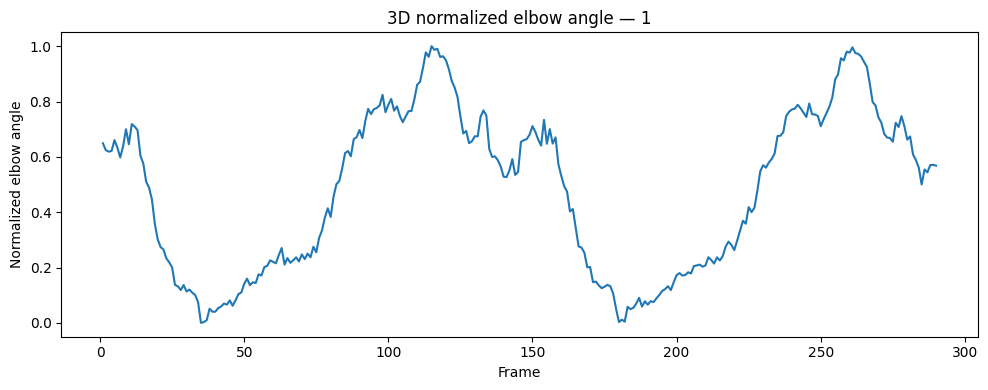

In [41]:
plt.figure(figsize=(10, 4))
plt.plot(plot_df_3d["frame"], plot_df_3d["elbow_angle_norm"])
plt.xlabel("Frame")
plt.ylabel("Normalized elbow angle")
plt.title(f"3D normalized elbow angle — {sample_video_3d}")
plt.tight_layout()
plt.show()

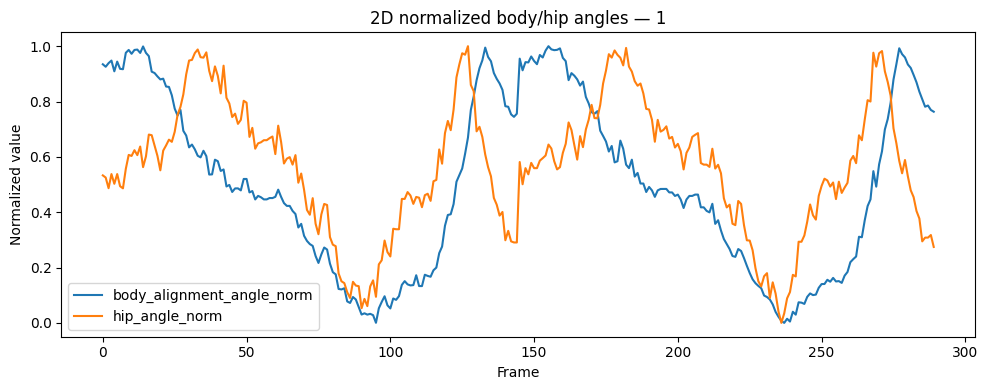

In [42]:
plt.figure(figsize=(10, 4))
plt.plot(plot_df_2d["frame"], plot_df_2d["body_alignment_angle_norm"], label="body_alignment_angle_norm")
plt.plot(plot_df_2d["frame"], plot_df_2d["hip_angle_norm"], label="hip_angle_norm")
plt.xlabel("Frame")
plt.ylabel("Normalized value")
plt.title(f"2D normalized body/hip angles — {sample_video_2d}")
plt.legend()
plt.tight_layout()
plt.show()

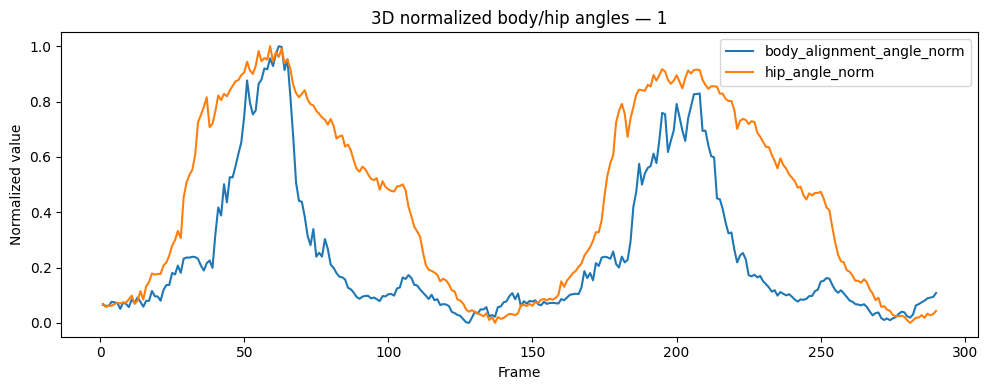

In [43]:
plt.figure(figsize=(10, 4))
plt.plot(plot_df_3d["frame"], plot_df_3d["body_alignment_angle_norm"], label="body_alignment_angle_norm")
plt.plot(plot_df_3d["frame"], plot_df_3d["hip_angle_norm"], label="hip_angle_norm")
plt.xlabel("Frame")
plt.ylabel("Normalized value")
plt.title(f"3D normalized body/hip angles — {sample_video_3d}")
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
display(
    df_2d[[
        "elbow_angle_norm",
        "body_alignment_angle_norm",
        "hip_angle_norm",
        "shoulder_wrist_distance_norm"
    ]].describe()
)

display(
    df_3d[[
        "elbow_angle_norm",
        "body_alignment_angle_norm",
        "hip_angle_norm",
        "shoulder_wrist_distance_norm"
    ]].describe()
)

,elbow_angle_norm,body_alignment_angle_norm,hip_angle_norm,shoulder_wrist_distance_norm
count,10928.000000,10928.000000,10928.000000,10928.000000
mean,0.657688,0.541587,0.536659,0.623085
std,0.354429,0.304841,0.288848,0.357510
min,0.000000,0.000000,0.000000,0.000000
25%,0.347245,0.269771,0.306218,0.271830
50%,0.831648,0.556940,0.537673,0.763759
75%,0.964943,0.823058,0.790313,0.954163
max,1.000000,1.000000,1.000000,1.000000


,elbow_angle_norm,body_alignment_angle_norm,hip_angle_norm,shoulder_wrist_distance_norm
count,10928.000000,10928.000000,10928.000000,10928.000000
mean,0.528690,0.316697,0.335092,0.539973
std,0.333936,0.314182,0.336440,0.357668
min,0.000000,0.000000,0.000000,0.000000
25%,0.212637,0.047372,0.038598,0.172162
50%,0.543960,0.183274,0.183617,0.582026
75%,0.861952,0.541667,0.612632,0.902812
max,1.000000,1.000000,1.000000,0.999998


In [45]:
OUTPUT_DIR = r"C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\processed"

os.makedirs(OUTPUT_DIR, exist_ok=True)

frame_2d_path = os.path.join(OUTPUT_DIR, "mmpose_2d_features_frame_level.csv")
frame_3d_path = os.path.join(OUTPUT_DIR, "mmpose_3d_features_frame_level.csv")

df_2d.to_csv(frame_2d_path, index=False)
df_3d.to_csv(frame_3d_path, index=False)

print("Saved 2D frame-level features to:", frame_2d_path)
print("Saved 3D frame-level features to:", frame_3d_path)

Saved 2D frame-level features to: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\processed\mmpose_2d_features_frame_level.csv
Saved 3D frame-level features to: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\processed\mmpose_3d_features_frame_level.csv


In [46]:
video_level_2d = (
    df_2d.groupby(["video", "label"], as_index=False)
    .agg(
        n_frames=("frame", "count"),
        elbow_angle_mean=("elbow_angle_norm", "mean"),
        elbow_angle_std=("elbow_angle_norm", "std"),
        body_alignment_angle_mean=("body_alignment_angle_norm", "mean"),
        hip_angle_mean=("hip_angle_norm", "mean"),
    )
)

video_level_3d = (
    df_3d.groupby(["video", "label"], as_index=False)
    .agg(
        n_frames=("frame", "count"),
        elbow_angle_mean=("elbow_angle_norm", "mean"),
        elbow_angle_std=("elbow_angle_norm", "std"),
        body_alignment_angle_mean=("body_alignment_angle_norm", "mean"),
        hip_angle_mean=("hip_angle_norm", "mean"),
    )
)

In [47]:
video_2d_path = os.path.join(OUTPUT_DIR, "mmpose_2d_features_video_level.csv")
video_3d_path = os.path.join(OUTPUT_DIR, "mmpose_3d_features_video_level.csv")

video_level_2d.to_csv(video_2d_path, index=False)
video_level_3d.to_csv(video_3d_path, index=False)

print("Saved 2D video-level features to:", video_2d_path)
print("Saved 3D video-level features to:", video_3d_path)

print("2D shape:", video_level_2d.shape)
print("3D shape:", video_level_3d.shape)

Saved 2D video-level features to: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\processed\mmpose_2d_features_video_level.csv
Saved 3D video-level features to: C:\Users\sebas\Documents\master_ai\05_dne\project\posture_checker\data\processed\mmpose_3d_features_video_level.csv
2D shape: (100, 7)
3D shape: (100, 7)
